In [1]:
import sys

sys.path.insert(1,"../src/")

from utilities import find_peaks, wideband_pulse
import warping

In [2]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp
from scipy.ndimage import label

In [3]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [4]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

NPERSEG = 80

NPEAKS = 20

In [203]:
wb_pulse_params = dict(pulse_duration=0.1, fs=SAMPLING_FREQ, bw=200, fc=350, window=sp.windows.hann)

In [204]:
data1 = scipy.io.loadmat("../data/field_values20260707/field_values20260707.mat")

f = data1['f'].squeeze()
c = data1['soundspeed'].squeeze()
Vg = data1['Vg'][:,:,c == TRUE_SOUNDSPEED,...].squeeze()
source_range = data1['range'][0,0]

In [205]:
df = f[1] - f[0]

#t0 = 0
t0 = source_range*1e3/1500
N = SAMPLING_FREQ/df

In [206]:
X = data1["g"][1, data1["soundspeed"]==TRUE_SOUNDSPEED].squeeze()

In [207]:
X = X  * np.exp(1j*2*np.pi*f*t0);
# x = np.real(np.ifft(X,N) * exp(1i*2*pi*(0:N-1)'*f(1)/SAMPLING_FREQ);

x = np.real(np.fft.ifft(X,int(N)) * np.exp(1j*2*np.pi*np.arange(N)*f[0]/SAMPLING_FREQ))
tx = np.arange(N)/SAMPLING_FREQ + t0

In [208]:
h = wideband_pulse(**wb_pulse_params)

x = sp.filtfilt(h, 1, x)

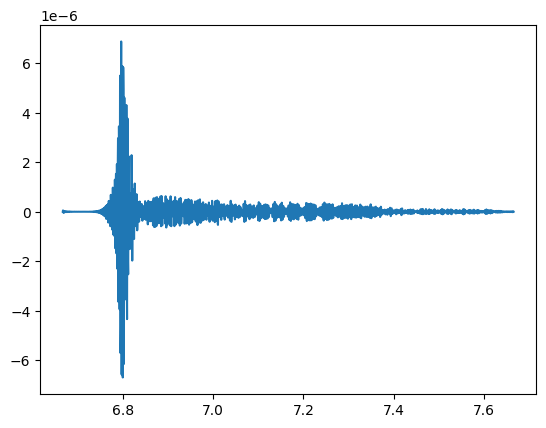

In [209]:
plt.plot(tx, x)

## Spectrogram Compared to Mode Curves

In [210]:
[w, t, X] = sp.spectrogram(x, SAMPLING_FREQ, 'hamm', NPERSEG, NPERSEG-1, 2000)
t = t + t0

w = w[201:502]
X = X[201:502, :]

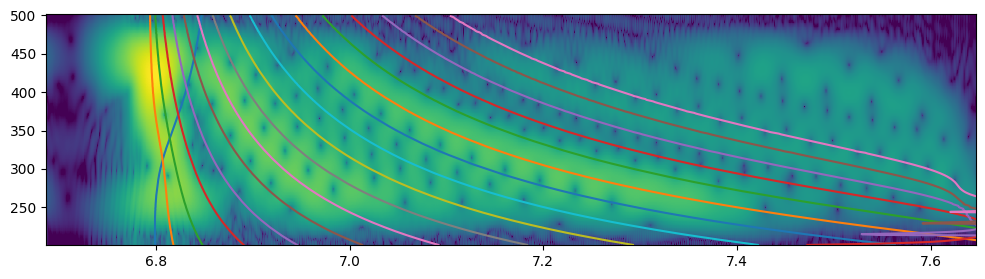

In [211]:
fig, ax = plt.subplots()
[low, high] = np.quantile(10*np.log10(X), [1e-2, 1])

ax.pcolormesh(t, w, 10*np.log10(X), vmin=low, vmax=high)

ax.plot(source_range*1e3/Vg.T, f[1:-1])
ax.set_xlim(t[[0, -1]])

fig.set_size_inches([12,3])


In [212]:
origin_time = 6.8

x_warped, tw, fsw = warping.nonlinear_warping(x[tx>=origin_time], SAMPLING_FREQ, t0)

In [279]:
nperseg = 1200
nfft = 2000
[ww, txw, Xw] = sp.stft(x_warped, fsw, 'hamm', nperseg, nperseg-1, nfft)
# peaksw = find_peaks(np.abs(Xw.mT)**2, txw, ww,10, np.quantile(np.abs(Xw)**2, .95))

In [280]:
Xw_bool = np.abs(Xw) > np.quantile(np.abs(Xw), 0.987)

In [281]:
labeled_data, nlabels = label(Xw_bool)

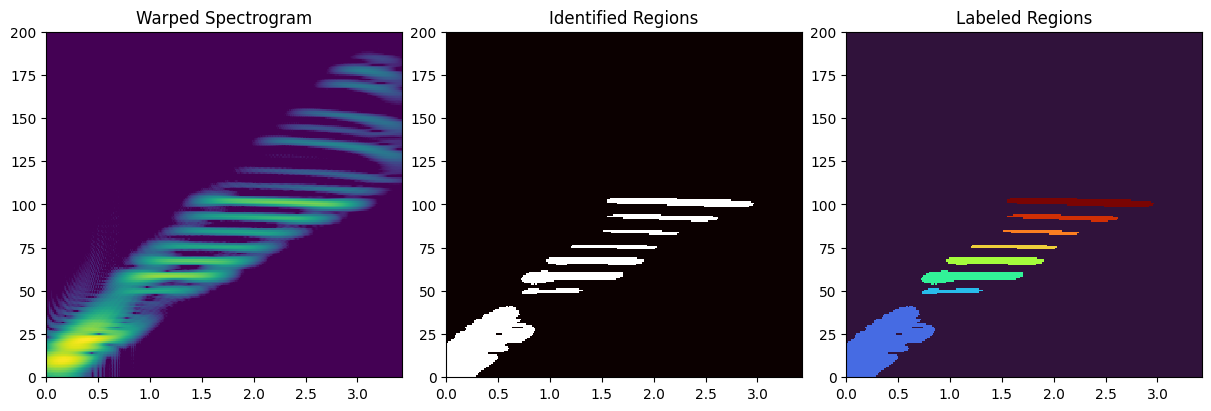

In [282]:
fig, (ax, axbool, axl) = plt.subplots(1,3, layout='constrained')

[vmin, vmax] = np.quantile(20*np.log10(np.abs(Xw)), [0.94, 1])

ax.pcolormesh(txw, ww, 20*np.log10(np.abs(Xw)), vmin=vmin, vmax=vmax)

#ax.scatter(peaksw[:,1], peaksw[:,0], c='orange', marker='x')

ax.set_ylim([0, 200])

ax.set_title("Warped Spectrogram")


axbool.pcolormesh(txw, ww, Xw_bool, cmap="hot")
axbool.set_ylim([0, 200])
axbool.set_title("Identified Regions")


axl.pcolormesh(txw, ww, labeled_data, cmap='turbo')
axl.set_ylim([0, 200])
axl.set_title("Labeled Regions")

fig.set_size_inches([12,4])

fig.savefig('../data/output/figures/timewarping_labeled.png', dpi=600)

In [233]:
# x_components = np.empty((nlabels, np.int64(N)))

for i_label in range(nlabels):
    mask_now = labeled_data == i_label
    X_comp_now = Xw * mask_now

    xnow = sp.istft(X_comp_now, fsw, 'hamm', nperseg, nperseg-1, nfft)[1]

    x_components[i_label] = warping.inv_nonlinear_warping(xnow, fsw, 6.8, SAMPLING_FREQ, N)[0]

[wc, tc, X_components] = sp.stft(x_components, SAMPLING_FREQ, 'hamm', NPERSEG, NPERSEG - 1, 2000)

fmask = np.all([wc>=200, wc<=500], 0) 
wc = wc[fmask]    
X_components = X_components[:, fmask, :]


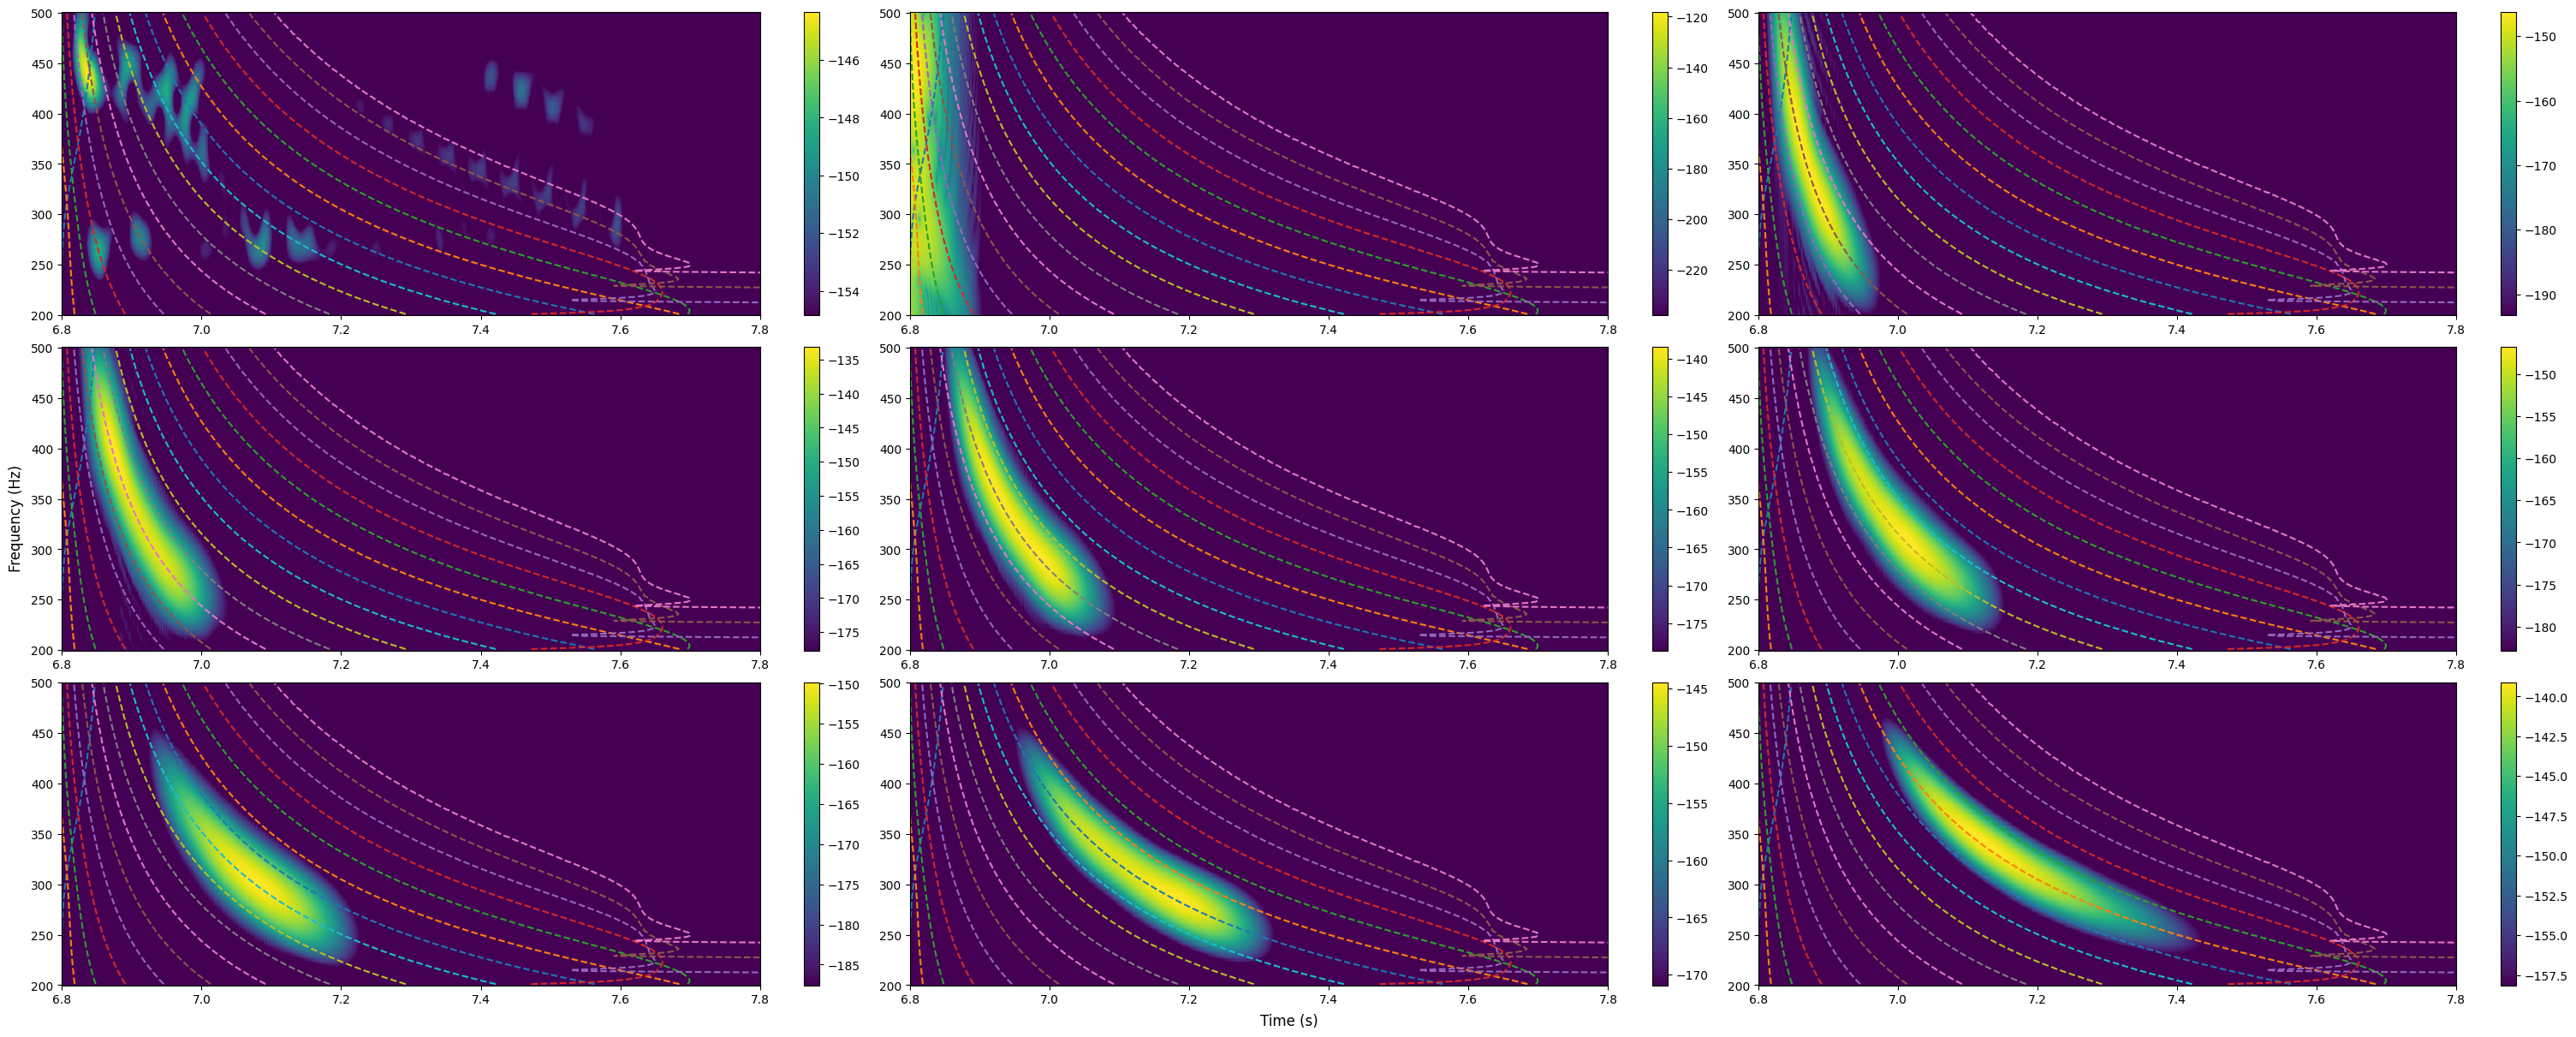

In [234]:
fig, ax = plt.subplots(3,3, layout='constrained')

vmin, vmax = np.quantile(20*np.log10(np.abs(X_components)), [.9, 1], [1,2])

plt.pcolormesh
for ind, sub in enumerate(np.ndindex(3,3)):
    m = ax[sub].pcolormesh(tc + 6.8, wc, 20*np.log10(np.abs(X_components[ind])), vmin=vmin[ind], vmax=vmax[ind])
    ax[sub].plot(source_range*1e3/Vg.T, f[1:-1], '--')
    ax[sub].set_xlim(tc[[0,-1]] + 6.8)

    plt.colorbar(m, ax=ax[sub])
fig.set_size_inches([30,12])    
fig.supxlabel('Time (s)')
fig.supylabel('Frequency (Hz)')
fig.savefig('../data/output/figures/timewarping_extracted_components.png', dpi=600)


In [296]:
peaks_components = list()

min_height = np.quantile(np.abs(X_components)**2, .9, [1,2])

for ind, Xc in enumerate(np.abs(X_components)**2):
    peaks_components.append(find_peaks(Xc.mT, tc + 6.8, wc, npeaks=1, min_height = min_height[ind]))


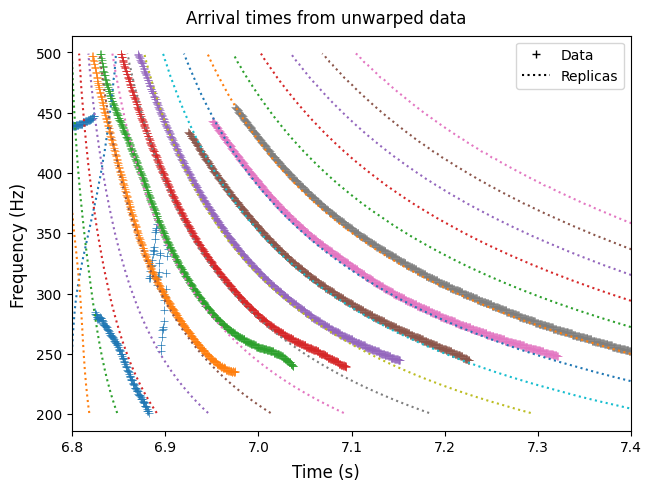

In [297]:
fig, ax = plt.subplots(layout='constrained')

for p in peaks_components[1:11]:
    ax.scatter(p[:,1], p[:,0], marker = '+', linewidths=.5)
ax.plot(source_range*1e3/Vg.T, f[1:-1], ':')
ax.set_xlim([6.8, 7.4])

ax.plot(0, 350, 'k+', label="Data")
ax.plot(0, 350, 'k:', label="Replicas")

ax.legend()

fig.supxlabel('Time (s)')
fig.supylabel('Frequency (Hz)')

fig.suptitle("Arrival times from unwarped data")
#fig.set_size_inches([30,12])    

fig.savefig('../data/output/figures/timewarping_arrival_times.png', dpi=600)

In [304]:
export = {'peaks_coordinates':np.array(peaks_components[5:], dtype=object), 'mode_nos':np.array([9,10,11,12])}

np.savez('../data/output/warping_arrival_times.npz', **export)

In [59]:
t = np.arange(201)/100

yy = np.sin(2*np.pi*5*t)

yyw, tyw, fsyw = warping.nonlinear_warping(yy, 100, 1e4/1500)
yuw, tyuw = warping.inv_nonlinear_warping(yyw, fsyw, 1e4/1500, 100, 201)

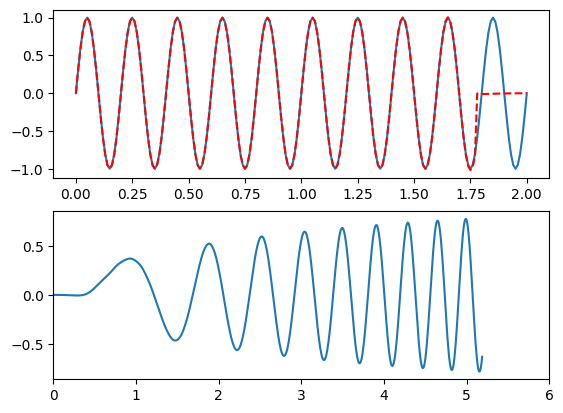

In [184]:
fig, ax = plt.subplots(2,1)

ax[0].plot(t,yy)
ax[1].plot(tyw, yyw)
ax[1].set_xlim([0,6])

ax[0].plot(t, yuw, 'r--')